In [140]:
import numpy as np
import tensorflow as tf
import sklearn as skl
import keras
import pandas as pd
import joblib

In [141]:
airfoil_data = pd.read_csv('utils/NACA23015.csv', sep=',', names=['x', 'y'])
AoA_effective_data = pd.read_csv('utils/LowFidelity-AoAEffectiveData.csv', sep=';')
panel_dx = np.diff(airfoil_data['x'].values).astype(np.float32)
panel_dy = np.diff(airfoil_data['y'].values).astype(np.float32)
X_scaler = joblib.load('utils/mlp_ann_X_scaler.pkl')
y_scaler = joblib.load('utils/mlp_ann_y_scaler.pkl')

In [142]:
N_INPUTS = 3
N_CP = 201
N_TAPS = 31
N_OUTPUTS = N_CP + 1

L2_FACTOR = 1e-5
LAMBDA_PHYSICAL = 0.1
LAMBDA_SMOOTH = 0.01

W_CL = 0.2
W_CP = 1.0

lf_model = keras.models.load_model('utils/MLP-ANN.keras', compile=False)
lf_model.trainable = False

def build_residual_multifidelity_model(lf_model, l2_factor=1e-5):
    """
    Builds a residual multi-fidelity neural network.

    The low-fidelity model predicts:
        [Cl_LF, Cp_LF_1, ..., Cp_LF_201]

    The correction network predicts:
        [Delta_Cl, Delta_Cp_1, ..., Delta_Cp_201]

    The final output is:
        [Cl_MF, Cp_MF_1, ..., Cp_MF_201]
    """

    inputs = keras.Input(shape=(N_INPUTS,), name='inputs')

    # ============================================================
    # Low-fidelity prediction
    # ============================================================

    lf_outputs = lf_model(inputs)

    cl_lf = lf_outputs[:, :1]
    cp_lf = lf_outputs[:, 1:]

    # ============================================================
    # Correction model input
    # ============================================================

    correction_input = keras.layers.Concatenate(name='correction_input')(
        [inputs, cl_lf, cp_lf]
    )

    # ============================================================
    # L2 regularization
    # ============================================================

    regularizer = keras.regularizers.l2(l2_factor)

    # ============================================================
    # High-fidelity residual correction network
    # ============================================================

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_1'
    )(correction_input)

    x = keras.layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_2'
    )(x)

    x = keras.layers.Dense(
        64,
        activation='swish',
        kernel_regularizer=regularizer,
        name='corr_dense_3'
    )(x)

    # ============================================================
    # Residual output
    # Important: zero initialization makes MF initially equal to LF
    # ============================================================

    delta_outputs = keras.layers.Dense(
        N_OUTPUTS,
        activation='linear',
        kernel_initializer='zeros',
        bias_initializer='zeros',
        kernel_regularizer=regularizer,
        name='delta_outputs'
    )(x)

    delta_cl = delta_outputs[:, :1]
    delta_cp = delta_outputs[:, 1:]

    # ============================================================
    # Residual multi-fidelity prediction
    # ============================================================

    cl_mf = keras.layers.Add(name='cl_mf')([cl_lf, delta_cl])
    cp_mf = keras.layers.Add(name='cp_mf')([cp_lf, delta_cp])

    outputs = keras.layers.Concatenate(name='outputs')([cl_mf, cp_mf])

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='residual_multifidelity_ann'
    )

    return model

keras.backend.clear_session()

lf_model = keras.models.load_model('utils/MLP-ANN.keras', compile=False)
lf_model.trainable = False

mf_model = build_residual_multifidelity_model(
    lf_model=lf_model,
    l2_factor=L2_FACTOR
)

mf_model.summary()

Model: "residual_multifidelity_ann"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ low_fidelity_mlp_a… │ (None, 202)       │    161,258 │ inputs[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1)         │          0 │ low_fidelity_mlp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 201)       │          0 │ low_fidelity_mlp… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correction_input    │ (None, 205)       │          0 │ inputs[0][0],     │
│ (Concatenate)       │                   │            │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ corr_dense_1        │ (None, 128)       │     26,368 │ correction_input… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ corr_dense_2        │ (None, 128)       │     16,512 │ corr_dense_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ corr_dense_3        │ (None, 64)        │      8,256 │ corr_dense_2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_outputs       │ (None, 202)       │     13,130 │ corr_dense_3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1)         │          0 │ delta_outputs[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 201)       │          0 │ delta_outputs[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cl_mf (Add)         │ (None, 1)         │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cp_mf (Add)         │ (None, 201)       │          0 │ get_item_1[0][0], │
│                     │                   │            │ get_item_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs             │ (None, 202)       │          0 │ cl_mf[0][0],      │
│ (Concatenate)       │                   │            │ cp_mf[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 225,524 (880.95 KB)

 Trainable params: 64,266 (251.04 KB)

 Non-trainable params: 161,258 (629.91 KB)

In [143]:
def build_resual_mf_pinn_loss(panel_dx: np.ndarray, panel_dy: np.ndarray, tap_indices: np.ndarray, lambda_physical: float,
    w_cl: float, w_cp: float, y_scaler: skl.preprocessing.StandardScaler, lambda_smooth):

    # converting gometry terms to tensorflow constants
    panel_dx = tf.constant(panel_dx, dtype=tf.float32)
    panel_dy = tf.constant(panel_dy, dtype=tf.float32)
    tap_indices = tf.constant(tap_indices, dtype=tf.int32)

    # output scaler parameters
    y_mean = y_scaler.mean_.astype(np.float32)
    y_scale = y_scaler.scale_.astype(np.float32)

    Cl_mean = tf.constant(y_mean[0:1].reshape(1, 1), dtype=tf.float32)
    Cl_scale = tf.constant(y_scale[0:1].reshape(1, 1), dtype=tf.float32)

    Cp_mean = tf.constant(y_mean[1:].reshape(1, -1), dtype=tf.float32)
    Cp_scale = tf.constant(y_scale[1:].reshape(1, -1), dtype=tf.float32)

    def pinn_loss(y_true, y_pred):

        #casting to float32
        y_true = tf.cast(y_true, dtype=tf.float32)   
        y_pred = tf.cast(y_pred, dtype=tf.float32)

        # extract true hf values
        Cl_true = y_true[:, 0:1]
        Cp_true_taps = y_true[:, 1:-1]
        AoA_deg = y_true[:, -1:]

        # extracts predicted mf values
        Cl_pred = y_pred[:, 0:1]
        Cp_pred = y_pred[:, 1:]

        Cp_pred_taps = tf.gather(Cp_pred, tap_indices, axis=1)

        # supervised loss
        Cl_loss = tf.reduce_mean(tf.square(Cl_true - Cl_pred))
        Cp_loss = tf.reduce_mean(tf.square(Cp_true_taps - Cp_pred_taps))
        data_loss = w_cl * Cl_loss + w_cp * Cp_loss

        # reescalses to physical units
        Cl_pred_raw = Cl_pred * Cl_scale + Cl_mean
        Cp_pred_raw = Cp_pred * Cp_scale + Cp_mean

        # physical loss
        panel_Cp = 0.5 * (Cp_pred_raw[:, :-1] + Cp_pred_raw[:, 1:])
        Cn = tf.reduce_sum(panel_Cp * panel_dx, axis=1, keepdims=True)
        Ca = -tf.reduce_sum(panel_Cp * panel_dy, axis=1, keepdims=True)

        AoA_rad = AoA_deg * (np.pi / 180.0)

        Cl_from_Cp_raw = (Cn * tf.cos(AoA_rad) - Ca * tf.sin(AoA_rad))

        physical_loss = tf.reduce_mean(tf.square(Cl_pred_raw - Cl_from_Cp_raw))

        d2Cp = (
            Cp_pred_raw[:, 2:]
            - 2.0 * Cp_pred_raw[:, 1:-1]
            + Cp_pred_raw[:, :-2]
        )

        smooth_loss = tf.reduce_mean(
            tf.square(d2Cp)
        )

        loss = data_loss + lambda_physical * physical_loss + lambda_smooth * smooth_loss

        return loss
    
    return pinn_loss

In [145]:
# indices dos taps experimentais
tap_indices = np.array([8, 14, 21, 27, 33, 39, 45, 50, 55, 60, 65, 71, 77, 84, 93, 103, 111, 119, 126, 132,
    137, 141, 145, 150, 156, 161, 167, 173, 179, 186, 192], dtype=np.int32)

x_cp_201 = np.array([float(col) for col in headers[4:]])

loss_fn = build_resual_mf_pinn_loss(
    panel_dx=panel_dx,
    panel_dy=panel_dy,
    tap_indices=tap_indices,
    lambda_physical=LAMBDA_PHYSICAL,
    lambda_smooth=LAMBDA_SMOOTH,
    w_cl=W_CL,
    w_cp=W_CP,
    y_scaler=y_scaler
)

mf_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0), loss=loss_fn)

In [ ]:
def match_effective_angle_cases(data, AoA_effective_data):

    hf_cases = data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)
    lf_cases = AoA_effective_data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)

    std_values = AoA_effective_data[['Re', 'AoA', 'y']].std().to_numpy(dtype=np.float64)

    AoA_effective_values = AoA_effective_data['AoA_Effective'].to_numpy(dtype=np.float64)

    matched_AoA_effective = []

    for case in hf_cases:
        distance = np.sqrt(
            ((lf_cases[:, 0] - case[0]) / std_values[0]) ** 2 +
            ((lf_cases[:, 1] - case[1]) / std_values[1]) ** 2 +
            ((lf_cases[:, 2] - case[2]) / std_values[2]) ** 2)
        
        closest_idx = np.argmin(distance)
        matched_AoA_effective.append(AoA_effective_values[closest_idx])

    matched_AoA_effective = np.array(matched_AoA_effective, dtype=np.float32)

    return matched_AoA_effective

In [ ]:
def load_and_split_data(filepath, AoA_effective):

    data = (pd.read_csv(filepath, sep=';')).copy()

    data['AoA_Effective'] = match_effective_angle_cases(data=data, AoA_effective_data=AoA_effective)
    
    wing_sections = 1
    idx = np.arange(len(data))
    data['flow_case'] = idx // wing_sections
    unique_cases = data['flow_case'].unique()
    train_cases, test_cases = skl.model_selection.train_test_split(unique_cases, test_size=0.2,
        random_state=42, shuffle=True)
    train_cases, val_cases = skl.model_selection.train_test_split(train_cases, test_size=0.2,
        random_state=42, shuffle=True)

    # --- Separate the datasets ---
    data_train = data[data['flow_case'].isin(train_cases)]
    data_val = data[data['flow_case'].isin(val_cases)].drop(columns=['flow_case'])
    data_test = data[data['flow_case'].isin(test_cases)]

    return data_train, data_val, data_test

def preprocess_data(data_train, data_val, data_test, X_scaler, y_scaler, tap_indices):

    tap_indices = np.array(tap_indices, dtype=int)

    X_cols = ['Re', 'AoA', 'y']
    y_cols = ['cl'] + [col for col in data_train.columns[4:] if col != 'AoA_Effective' and col != 'flow_case']

    X_train_raw = data_train[X_cols].to_numpy()
    X_val_raw = data_val[X_cols].to_numpy()
    X_test_raw = data_test[X_cols].to_numpy()

    AoA_train_raw = data_train[['AoA_Effective']].to_numpy()
    AoA_val_raw = data_val[['AoA_Effective']].to_numpy()
    AoA_test_raw = data_test[['AoA_Effective']].to_numpy()

    y_train_raw = data_train[y_cols].to_numpy()
    y_val_raw = data_val[y_cols].to_numpy()
    y_test_raw = data_test[y_cols].to_numpy()

    X_train = X_scaler.transform(X_train_raw)
    X_val = X_scaler.transform(X_val_raw)
    X_test = X_scaler.transform(X_test_raw)

    def scale_hf_targets(y_raw, AoA_raw):
        cl_raw = y_raw[:, :1]
        cp_raw = y_raw[:, 1:]

        cl_mean = y_scaler.mean_[0]
        cl_scale = y_scaler.scale_[0]

        cp_means = y_scaler.mean_[1:][tap_indices]
        cp_scales = y_scaler.scale_[1:][tap_indices]

        cl_scaled = (cl_raw - cl_mean) / cl_scale
        cp_scaled = (cp_raw - cp_means.reshape(1, -1)) / cp_scales.reshape(1, -1)

        y_scaled = np.hstack((cl_scaled, cp_scaled))

        y_final = np.hstack((y_scaled, AoA_raw))

        return y_final
    
    y_train = scale_hf_targets(y_train_raw, AoA_train_raw)
    y_val = scale_hf_targets(y_val_raw, AoA_val_raw)
    y_test = scale_hf_targets(y_test_raw, AoA_test_raw)

    return X_train, y_train, X_val, y_val, X_test, y_test


data_train, data_val, data_test = load_and_split_data('utils/HighFidelity-Aviation-PressureDistributionData.csv', AoA_effective_data) 
data_train.head(5)

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(data_train, data_val, data_test, X_scaler, y_scaler, tap_indices)

callbacks = [
    keras.callbacks.TerminateOnNaN(),

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        min_delta=1e-6,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        cooldown=5,
        min_delta=1e-5,
        min_lr=1e-7
    )
]
history = mf_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5000, batch_size=64, callbacks=callbacks)

Epoch 1/5000


AttributeError: SymbolicTensor object has no attribute 'reshape'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      

         loss  val_loss  learning_rate
444  0.333132  0.235321       0.000003
445  0.333046  0.235293       0.000003
446  0.333109  0.235356       0.000003
447  0.333086  0.235329       0.000003
448  0.333033  0.235306       0.000003


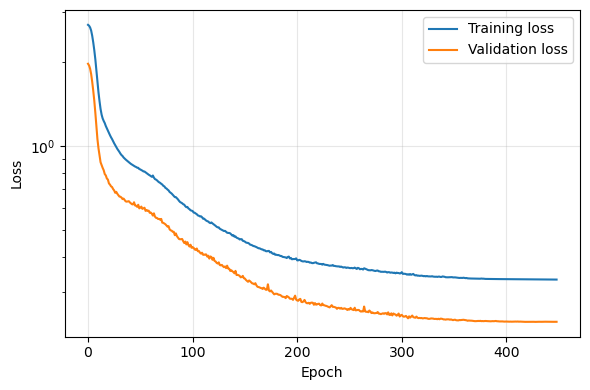

In [ ]:
from matplotlib import pyplot as plt

history_df = pd.DataFrame(history.history)
print(history_df.tail())

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
pred_train = mf_model.predict(X_train)
pred_val = mf_model.predict(X_val)
pred_test = mf_model.predict(X_test)

cl_train_pred = pred_train[:, :1]
cp_train_pred = pred_train[:, 1:]

cl_val_pred = pred_val[:, :1]
cp_val_pred = pred_val[:, 1:]

cl_test_pred = pred_test[:, :1]
cp_test_pred = pred_test[:, 1:]

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
cl_train_true = y_train[:, :1]
cp_train_true_taps = y_train[:, 1:-1]
aoa_train_eff = y_train[:, -1:]

cl_val_true = y_val[:, :1]
cp_val_true_taps = y_val[:, 1:-1]
aoa_val_eff = y_val[:, -1:]

cl_test_true = y_test[:, :1]
cp_test_true_taps = y_test[:, 1:-1]
aoa_test_eff = y_test[:, -1:]

cp_train_pred_taps = cp_train_pred[:, tap_indices]
cp_val_pred_taps = cp_val_pred[:, tap_indices]
cp_test_pred_taps = cp_test_pred[:, tap_indices]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def regression_metrics(y_true, y_pred, name=''):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

    return {
        'case': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

metrics_scaled = pd.DataFrame([
    regression_metrics(cp_train_true_taps, cp_train_pred_taps, 'Train Cp taps'),
    regression_metrics(cp_val_true_taps, cp_val_pred_taps, 'Val Cp taps'),
    regression_metrics(cp_test_true_taps, cp_test_pred_taps, 'Test Cp taps'),

    regression_metrics(cl_train_true, cl_train_pred, 'Train Cl'),
    regression_metrics(cl_val_true, cl_val_pred, 'Val Cl'),
    regression_metrics(cl_test_true, cl_test_pred, 'Test Cl'),
])

print(metrics_scaled)

            case       MSE      RMSE       MAE        R2
0  Train Cp taps  0.328185  0.572874  0.195107  0.889954
1    Val Cp taps  0.229949  0.479530  0.192573  0.896525
2   Test Cp taps  0.531932  0.729337  0.223227  0.826640
3       Train Cl  0.002884  0.053699  0.040658  0.994268
4         Val Cl  0.003545  0.059541  0.047462  0.992504
5        Test Cl  0.004428  0.066542  0.049169  0.991767


In [ ]:
def inverse_transform_full_output(y_scaled, y_scaler):
    return y_scaled * y_scaler.scale_.reshape(1, -1) + y_scaler.mean_.reshape(1, -1)

pred_test_raw = inverse_transform_full_output(pred_test, y_scaler)

cl_test_pred_raw = pred_test_raw[:, :1]
cp_test_pred_raw = pred_test_raw[:, 1:]

def inverse_transform_hf_targets(y_hf_scaled, y_scaler, tap_indices):
    cl_scaled = y_hf_scaled[:, :1]
    cp_scaled = y_hf_scaled[:, 1:-1]
    aoa_raw = y_hf_scaled[:, -1:]

    cl_raw = cl_scaled * y_scaler.scale_[0] + y_scaler.mean_[0]

    cp_means = y_scaler.mean_[1:][tap_indices].reshape(1, -1)
    cp_scales = y_scaler.scale_[1:][tap_indices].reshape(1, -1)

    cp_raw = cp_scaled * cp_scales + cp_means

    return cl_raw, cp_raw, aoa_raw

cl_test_true_raw, cp_test_true_taps_raw, aoa_test_eff_raw = inverse_transform_hf_targets(
    y_test, y_scaler, tap_indices
)

cp_test_pred_taps_raw = cp_test_pred_raw[:, tap_indices]

In [ ]:
metrics_raw = pd.DataFrame([
    regression_metrics(cp_test_true_taps_raw, cp_test_pred_taps_raw, 'Test Cp taps raw'),
    regression_metrics(cl_test_true_raw, cl_test_pred_raw, 'Test Cl raw'),
])

print(metrics_raw)

               case       MSE      RMSE       MAE        R2
0  Test Cp taps raw  0.003987  0.063143  0.035819  0.990016
1       Test Cl raw  0.000653  0.025546  0.018876  0.991767


In [ ]:
lf_test = lf_model.predict(X_test)
lf_test_raw = inverse_transform_full_output(lf_test, y_scaler)

cl_lf_test_raw = lf_test_raw[:, :1]
cp_lf_test_raw = lf_test_raw[:, 1:]

cp_lf_test_taps_raw = cp_lf_test_raw[:, tap_indices]

comparison_raw = pd.DataFrame([
    regression_metrics(cp_test_true_taps_raw, cp_lf_test_taps_raw, 'LF Cp taps raw'),
    regression_metrics(cp_test_true_taps_raw, cp_test_pred_taps_raw, 'MF Cp taps raw'),

    regression_metrics(cl_test_true_raw, cl_lf_test_raw, 'LF Cl raw'),
    regression_metrics(cl_test_true_raw, cl_test_pred_raw, 'MF Cl raw'),
])

print(comparison_raw)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
             case       MSE      RMSE       MAE        R2
0  LF Cp taps raw  0.091514  0.302513  0.170808  0.770842
1  MF Cp taps raw  0.003987  0.063143  0.035819  0.990016
2       LF Cl raw  0.023068  0.151880  0.132109  0.708962
3       MF Cl raw  0.000653  0.025546  0.018876  0.991767


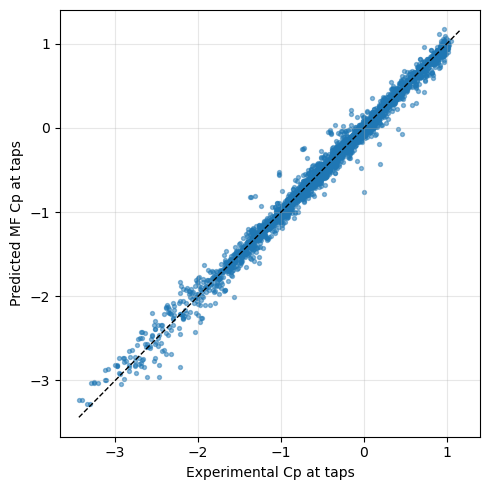

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(cp_test_true_taps_raw.reshape(-1), cp_test_pred_taps_raw.reshape(-1), s=8, alpha=0.5)

min_val = min(cp_test_true_taps_raw.min(), cp_test_pred_taps_raw.min())
max_val = max(cp_test_true_taps_raw.max(), cp_test_pred_taps_raw.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

plt.xlabel('Experimental Cp at taps')
plt.ylabel('Predicted MF Cp at taps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

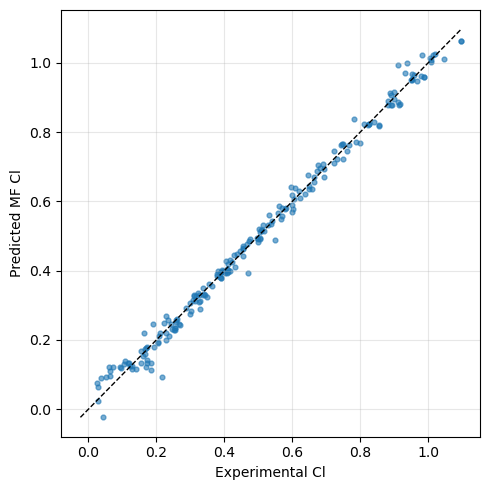

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(cl_test_true_raw.reshape(-1), cl_test_pred_raw.reshape(-1), s=12, alpha=0.6)

min_val = min(cl_test_true_raw.min(), cl_test_pred_raw.min())
max_val = max(cl_test_true_raw.max(), cl_test_pred_raw.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

plt.xlabel('Experimental Cl')
plt.ylabel('Predicted MF Cl')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

                            case       MSE     RMSE       MAE        R2
0  MF Cl predicted vs integrated  0.000077  0.00879  0.006726  0.999023


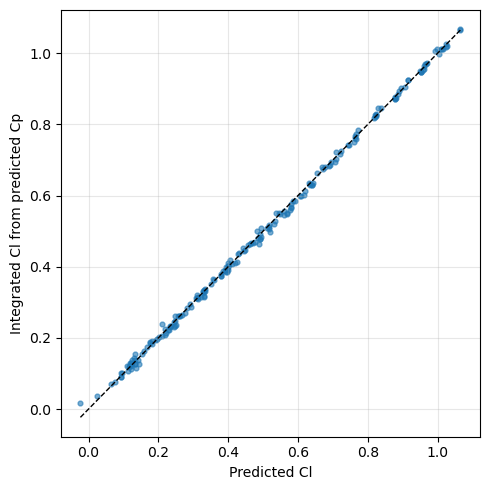

In [ ]:
def integrate_cp_to_cl_numpy(cp_raw, aoa_deg, panel_dx, panel_dy):
    panel_cp = 0.5 * (cp_raw[:, :-1] + cp_raw[:, 1:])

    cn = np.sum(panel_cp * panel_dx.reshape(1, -1), axis=1, keepdims=True)
    ca = -np.sum(panel_cp * panel_dy.reshape(1, -1), axis=1, keepdims=True)

    aoa_rad = aoa_deg * np.pi / 180.0

    cl_from_cp = cn * np.cos(aoa_rad) - ca * np.sin(aoa_rad)

    return cl_from_cp

cl_test_from_cp_raw = integrate_cp_to_cl_numpy(
    cp_test_pred_raw,
    aoa_test_eff_raw,
    panel_dx,
    panel_dy
)

physics_metrics = pd.DataFrame([
    regression_metrics(cl_test_pred_raw, cl_test_from_cp_raw, 'MF Cl predicted vs integrated'),
])

print(physics_metrics)

plt.figure(figsize=(5, 5))
plt.scatter(cl_test_pred_raw.reshape(-1), cl_test_from_cp_raw.reshape(-1), s=12, alpha=0.6)

min_val = min(cl_test_pred_raw.min(), cl_test_from_cp_raw.min())
max_val = max(cl_test_pred_raw.max(), cl_test_from_cp_raw.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

plt.xlabel('Predicted Cl')
plt.ylabel('Integrated Cl from predicted Cp')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

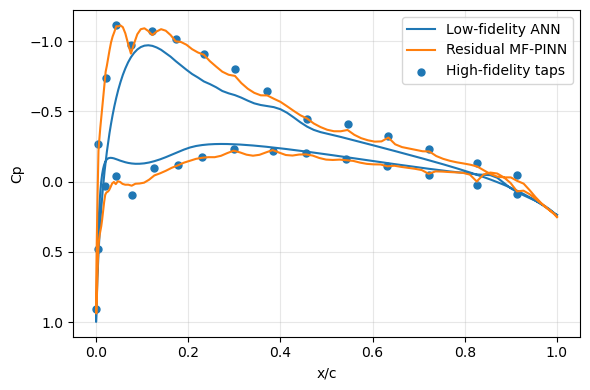

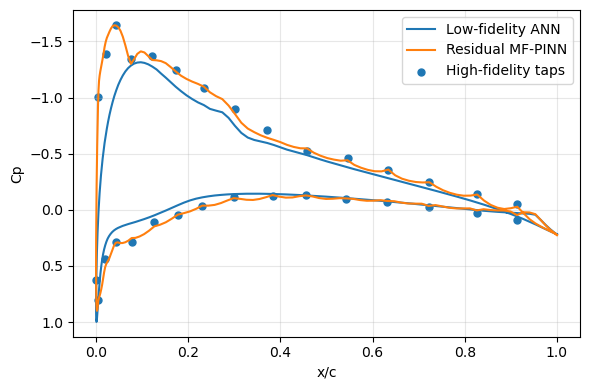

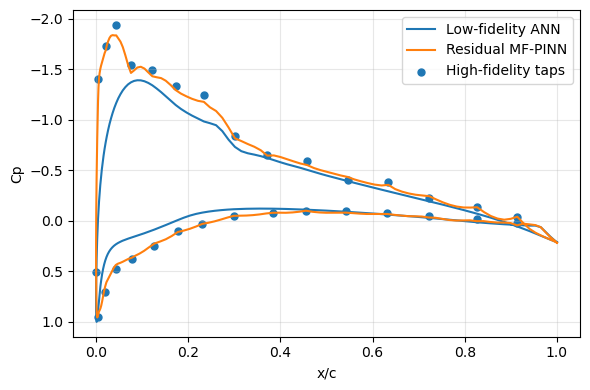

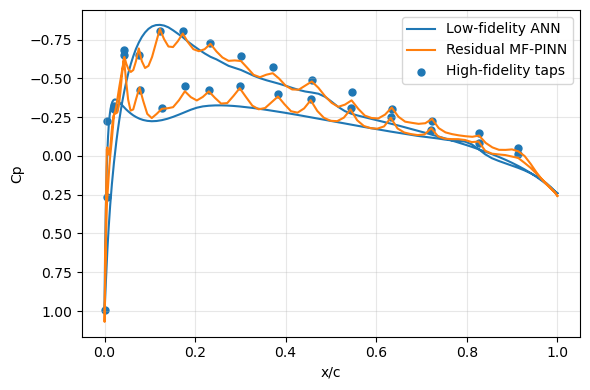

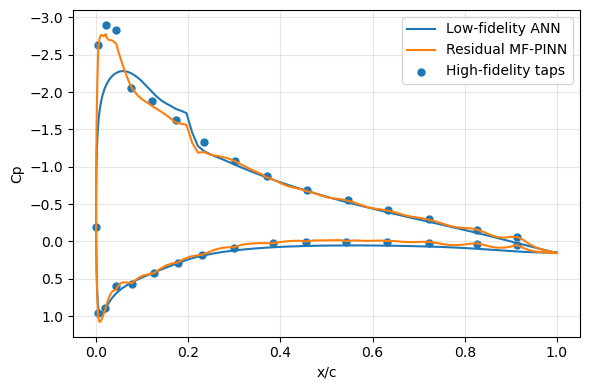

In [ ]:
with open('utils/LowFidelity-PressureDistributionData.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')

x_cp_201 = np.array([float(col) for col in headers[4:]])

x_cp_taps = x_cp_201[tap_indices]

def plot_cp_case(i):
    plt.figure(figsize=(6, 4))

    plt.plot(x_cp_201, cp_lf_test_raw[i], label='Low-fidelity ANN', linewidth=1.5)
    plt.plot(x_cp_201, cp_test_pred_raw[i], label='Residual MF-PINN', linewidth=1.5)
    plt.scatter(x_cp_taps, cp_test_true_taps_raw[i], label='High-fidelity taps', s=25)

    plt.gca().invert_yaxis()
    plt.xlabel('x/c')
    plt.ylabel('Cp')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for i in [200, 202, 204, 205, 206]:
    plot_cp_case(i)